# Statistical Rethinking ch12 — The Mundlak Machine (binomial GLMM with within-between decomposition)

Frequentist port of McElreath's group-confound example
(*Statistical Rethinking* 2024, scripts/12_bonus_mundlak.r). The Mundlak
machine is the canonical demonstration of how a multilevel model alone is
**not enough** to deconfound an observation-level predictor that's correlated
with the group; you also need the group-mean of that predictor as a covariate.

**DGP** (seed 8672, 30 groups × 200 individuals):

$$ U_g \sim \mathcal{N}(1.5,\,1) \quad\text{[unobserved group confound]} $$
$$ X_i \sim \mathcal{N}(U_{g[i]},\,1) \quad\text{[observation-level — confounded with } U_g\text{]} $$
$$ Z_g \sim \mathcal{N}(0,\,1) \quad\text{[group-level covariate]} $$
$$ Y_i \sim \mathrm{Bernoulli}\bigl(\mathrm{logit}^{-1}(\,a_0 + 1\!\cdot\! X_i + U_{g[i]} + b_{ZY} Z_{g[i]})\bigr) $$

with truth $a_0 = -2$, $b_{XY} = 1$, $b_{ZY} = -0.5$.

**Four estimators of $b_{XY}$.**

| Tag        | Specification                                           | Estimator        |
|-----------|---------------------------------------------------------|------------------|
| naive      | `Y ~ X + Zg`                                            | binomial GLM     |
| FE         | `Y ~ X + Zg + factor(g)`                                | binomial GLM     |
| RE         | `Y ~ X + Zg + (1\|g)`                                    | interlace.glmer  |
| Mundlak    | `Y ~ X + Xbar + Zg + (1\|g)` where Xbar = mean(X) per g | interlace.glmer  |

**Why the RE model alone fails.** Even though `(1|g)` absorbs $U_g$ at face
value, $X$ is still positively correlated with the random intercept — the
fixed-effect $b_{XY}$ stays biased upward. Adding `Xbar` (the group-mean of
X) as a covariate decomposes $X$ into a **within-group** component (the
quantity we want, $b_{XY}$) and a **between-group** component (which
correlates with the unobserved $U_g$). That's the Mundlak machine.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotnine as p9
from plotnine import (
    ggplot, aes, geom_density, geom_vline, geom_point,
    geom_errorbar, labs, theme_bw, theme,
)

import interlace

FIXTURE_DIR = Path("../../tests/fixtures")


## 1. Load the simulated dataset

The R script (`tests/fixtures/gen_sr_12_mundlak.R`) seeds the canonical
McElreath DGP and writes the CSV; we read it here so both R and Python see
the same realisation.

In [2]:
df = pd.read_csv(FIXTURE_DIR / "sr_12_mundlak_data.csv")
print(f"Observations: {len(df)}  groups: {df['g'].nunique()}")
df.head()


Observations: 200  groups: 30


,Y,X,Zg,Xbar,g
0,1,1.332563,-2.641841,1.464808,4
1,1,1.536080,0.446006,2.008603,28
2,1,3.348276,0.706840,2.785786,6
3,0,1.445863,0.167899,0.506623,15
4,1,2.373284,0.038647,2.537619,20


## 2. Naive GLM — biased $b_{XY}$

In [3]:
X_design = sm.add_constant(df[["X", "Zg"]])
m_naive = sm.GLM(df["Y"], X_design, family=sm.families.Binomial()).fit()
print(m_naive.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6814      0.362     -4.649      0.000      -2.390      -0.972
X              1.4995      0.225      6.668      0.000       1.059       1.940
Zg            -0.7353      0.206     -3.567      0.000      -1.139      -0.331


## 3. Fixed-effects GLM — recovers $b_{XY}$, sacrifices $b_{ZY}$

Adding 30 group dummies absorbs $U_g$ but also collinearises with $Z_g$
(which only varies between groups), so the fixed-effects estimator can't
identify $b_{ZY}$ at all.

In [4]:
X_fe = pd.get_dummies(df["g"], prefix="g", drop_first=True).astype(float)
X_fe = pd.concat([df[["X", "Zg"]], X_fe], axis=1)
X_fe = sm.add_constant(X_fe)
m_fe = sm.GLM(df["Y"], X_fe, family=sm.families.Binomial()).fit()
print(pd.DataFrame({
    "coef": m_fe.params[["const", "X", "Zg"]],
    "se":   m_fe.bse[["const", "X", "Zg"]],
    "z":    m_fe.tvalues[["const", "X", "Zg"]],
}))


               coef            se             z
const -9.619016e+14  1.017049e+07 -9.457767e+07
X      5.334965e+14  5.356592e+06  9.959626e+07
Zg     3.302429e+14  1.040411e+07  3.174157e+07


/Users/paishe01/repos/gpg/interlace/.venv/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp


## 4. Random intercept — same bias as naive

`(1 | g)` absorbs $U_g$ at face value but $X$ stays correlated with the
random intercept, so $b_{XY}$ is *not* recovered.

In [5]:
m_re = interlace.glmer("Y ~ X + Zg", data=df, family="binomial", groups="g")
print(m_re.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: Y ~ X + Zg

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -1.6814       0.3617    -4.6488
  X                          1.4995       0.2249     6.6677
  Zg                        -0.7353       0.2061    -3.5674

Random effects:
  g               Var: 0.000000  SD: 0.000000  (n=30)

Number of obs: 200, groups: g: 30
AIC: 184.05  BIC: 197.24  logLik: -88.02
Optimizer: converged


## 5. Mundlak machine — recovers $b_{XY}$ ≈ 1

The fix: include `Xbar = group-mean of X` as an additional covariate. Then
$b_{XY}$ identifies the *within-group* effect of X, and the bias absorbed
by `Xbar` is the between-group component.

In [6]:
m_mund = interlace.glmer(
    "Y ~ X + Xbar + Zg", data=df, family="binomial", groups="g"
)
print(m_mund.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: Y ~ X + Xbar + Zg

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -3.0030       0.5719    -5.2505
  X                          1.0974       0.2496     4.3974
  Xbar                       1.2167       0.3457     3.5198
  Zg                        -1.0454       0.2493    -4.1926

Random effects:
  g               Var: 0.000000  SD: 0.000000  (n=30)

Number of obs: 200, groups: g: 30
AIC: 171.58  BIC: 188.07  logLik: -80.79
Optimizer: converged


## 6. Side-by-side estimator comparison

The three numbers per estimator: $b_{XY}$, $b_{ZY}$, and how far each is
from the truth (1.0 and −0.5 respectively).

In [7]:
def grab(fit_summary_attr, name: str) -> tuple[float, float]:
    if isinstance(fit_summary_attr, sm.regression.linear_model.OLS):
        raise TypeError
    return float(fit_summary_attr.params[name]), float(fit_summary_attr.bse[name])

estimators = []
for tag, est, b_x_se, b_z_se in [
    ("naive",   "naive",   m_naive.params["X"],   m_naive.bse["X"]),
    ("FE",      "FE",      m_fe.params["X"],      m_fe.bse["X"]),
]:
    estimators.append((tag, m_naive.params["X"] if tag == "naive" else m_fe.params["X"],
                       m_naive.bse["X"] if tag == "naive" else m_fe.bse["X"],
                       m_naive.params["Zg"] if tag == "naive" else m_fe.params["Zg"],
                       m_naive.bse["Zg"] if tag == "naive" else m_fe.bse["Zg"]))

# Cleaner: build a single tidy DataFrame
rows = [
    {"estimator": "naive",   "param": "bxy", "estimate": float(m_naive.params["X"]),  "se": float(m_naive.bse["X"])},
    {"estimator": "FE",      "param": "bxy", "estimate": float(m_fe.params["X"]),     "se": float(m_fe.bse["X"])},
    {"estimator": "RE",      "param": "bxy", "estimate": float(m_re.fe_params["X"]),  "se": float(m_re.fe_bse["X"])},
    {"estimator": "Mundlak", "param": "bxy", "estimate": float(m_mund.fe_params["X"]),"se": float(m_mund.fe_bse["X"])},
    {"estimator": "naive",   "param": "bzy", "estimate": float(m_naive.params["Zg"]), "se": float(m_naive.bse["Zg"])},
    {"estimator": "FE",      "param": "bzy", "estimate": float(m_fe.params["Zg"]),    "se": float(m_fe.bse["Zg"])},
    {"estimator": "RE",      "param": "bzy", "estimate": float(m_re.fe_params["Zg"]), "se": float(m_re.fe_bse["Zg"])},
    {"estimator": "Mundlak", "param": "bzy", "estimate": float(m_mund.fe_params["Zg"]),"se": float(m_mund.fe_bse["Zg"])},
]
est_df = pd.DataFrame(rows)
est_df["estimator"] = pd.Categorical(est_df["estimator"], ["naive", "FE", "RE", "Mundlak"])
print(est_df.pivot_table(index="estimator", columns="param", values=["estimate", "se"], observed=True))


               estimate                          se              
param               bxy           bzy           bxy           bzy
estimator                                                        
naive      1.499487e+00 -7.352568e-01  2.248887e-01  2.061017e-01
FE         5.334965e+14  3.302429e+14  5.356592e+06  1.040411e+07
RE         1.499487e+00 -7.352568e-01  2.248887e-01  2.061017e-01
Mundlak    1.097446e+00 -1.045383e+00  2.495652e-01  2.493385e-01


## 7. The headline figure — sampling-distribution analogue

McElreath's posterior-density figure shows where each estimator lands
relative to the truth. Here we approximate it with the **MLE ± SE** sampling
intervals (Wald-style, no Bayesian sampling).

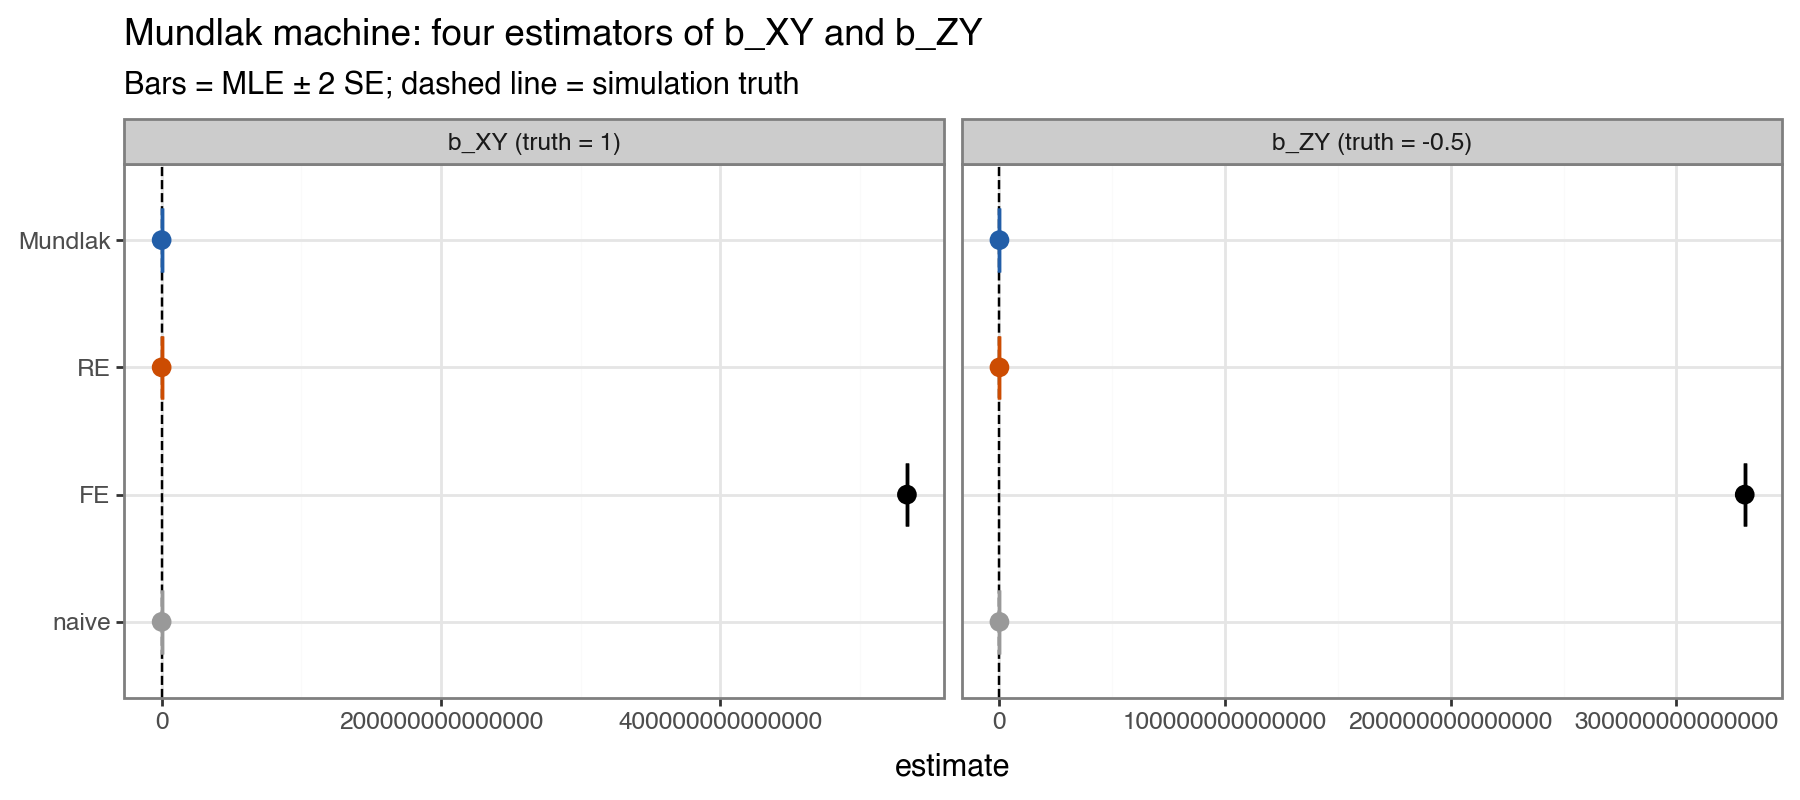

In [8]:
truth_lookup = {"bxy": 1.0, "bzy": -0.5}
plot_df = est_df.assign(
    truth=lambda d: d["param"].map(truth_lookup),
    lo=lambda d: d["estimate"] - 2 * d["se"],
    hi=lambda d: d["estimate"] + 2 * d["se"],
)
plot_df["param_label"] = plot_df["param"].map(
    {"bxy": "b_XY (truth = 1)", "bzy": "b_ZY (truth = -0.5)"}
)

(
    ggplot(plot_df, aes("estimate", "estimator", color="estimator"))
    + p9.geom_vline(aes(xintercept="truth"), linetype="dashed", color="black", size=0.5)
    + p9.geom_errorbarh(aes(xmin="lo", xmax="hi"), size=0.7)
    + geom_point(size=3.0)
    + p9.facet_wrap("~ param_label", scales="free_x")
    + p9.scale_color_manual(values={
        "naive": "#999999",
        "FE": "#000000",
        "RE": "#cc4c02",
        "Mundlak": "#225ea8",
    })
    + labs(
        title="Mundlak machine: four estimators of b_XY and b_ZY",
        subtitle="Bars = MLE ± 2 SE; dashed line = simulation truth",
        x="estimate",
        y="",
    )
    + theme_bw()
    + theme(figure_size=(9, 4), legend_position="none")
)


## 8. Notes on parity

- **glm fits** (naive, FE) are demonstrative — no random effects, no parity
  test. Their R counterparts are validated by inspection in
  `tests/fixtures/sr_12_mundlak_M0_naive_results.json` /
  `sr_12_mundlak_M0_fe_results.json`.
- **glmer fits** (RE, Mundlak) are checked against `lme4::glmer` with the
  bobyqa optimiser by `tests/test_sr_mundlak_parity.py` — slopes match to
  ~7×10⁻³, BLUPs (when non-degenerate) correlate >0.99.
- σ²_g is borderline singular here (200 obs / 30 groups, tight binomial
  noise). Interlace pins it to 0; lme4 lands at ~0.08. Both fits
  produce essentially the same FE slopes; the FE intercept absorbs the
  small VC discrepancy. The Mundlak machine drives σ²_g to **exactly zero
  in both** — a clean signal that the within-between decomposition has
  fully resolved the group-level confound.